<a href="https://colab.research.google.com/github/reyesborborjohnny/machine-learning-python-template.-JohnnyReyesBorbor/blob/main/Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
from google.colab import drive
import zipfile
import shutil
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.image import imread
from keras.models import Sequential, Model, load_model
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
import keras
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
import joblib
import requests
import json
import pickle
import math
import seaborn as sns
import pandas as pd
import numpy as np
from numpy._core.defchararray import upper
from pathlib import Path
from tabulate import tabulate
import psutil
import shutil
import tensorflow as tf
from keras.applications import VGG16
import datetime
from google.colab import drive
import re
from keras.preprocessing import image


**Paso 1: Carga del conjunto de datos**

El conjunto de datos se encuentra en este link. Descarga la carpeta y descomprime los archivos. Ahora tendrás una carpeta con el dataset y una carpeta llamada train que contiene más de 25.000 archivos de imagen (formato .jpg) de perros y gatos. Las fotos están etiquetadas por su nombre de archivo, con la palabra dog o cat.

In [26]:
drive.mount('/content/drive')

zip_drive = '/content/drive/MyDrive/Colab Notebooks/dogs-vs-cats.zip'
zip_local = '/content/dogs-vs-cats.zip'
extract_path = '/content/dataset'

# Copiar zip al disco local
shutil.copy(zip_drive, zip_local)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_local, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping finished!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping finished!


**Paso 2: Visualiza la información de entrada**

El primer paso cuando nos enfrentamos a un problema de clasificación de imágenes es obtener toda la información posible a través de ellas. Por lo tanto, carga e imprime las primeras nueve fotos de perros en una sola figura. Repite lo mismo para los gatos. Puedes ver que las fotos son a color y tienen diferentes formas y tamaños.

Esta variedad de tamaños y formatos debe solucionarse antes de entrenar el modelo. Asegúrate de que todas tengan un tamaño fijo de 200x200 píxeles.

Como podrás ver, son una gran cantidad de imágenes, asegúrate de seguir las siguientes normas:

Si tienes más de 12 gigabytes de RAM, usa la API de procesamiento de imágenes de Keras para cargar las 25.000 fotos en el conjunto de datos de entrenamiento y remodelarlas a fotos cuadradas de 200×200 píxeles. La etiqueta también debe determinarse para cada foto en función de los nombres de archivo. Se debe guardar una tupla de fotos y etiquetas.
Si no tienes más de 12 gigabytes de RAM, carga las imágenes progresivamente usando la clase Keras ImageDataGenerator y la función flow_from_directory(). Esto será más lento de ejecutar, pero se ejecutará en hardware de menor capacidad. Esta función prefiere que los datos se dividan en directorios train y test separados, y debajo de cada directorio para tener un subdirectorio para cada clase.
Una vez tengas todas las imágenes procesadas, crea un objeto ImageDataGenerator para datos de entrenamiento y prueba. Luego pasa la carpeta que tiene datos de entrenamiento al objeto trdata y, de manera similar, pasa la carpeta que tiene datos de prueba al objeto tsdata. De esta forma, se etiquetarán las imágenes automáticamente y estará todo listo para entrar a la red.

In [27]:
path1 = '/content/dataset/dogs-vs-cats/train'
path2 = '/content/data/processed'
train_dir = os.path.join(path2, 'train')
test_dir = os.path.join(path2, 'test')
for raiz in [train_dir, test_dir]:
    for animal in ['dog', 'cat']:
        os.makedirs(os.path.join(raiz, animal), exist_ok=True)
fotos = [f for f in os.listdir(path1) if f.endswith('.jpg')]
fotos.sort()
for i, filename in enumerate(fotos):
    categoria = 'dog' if filename.startswith('dog') else 'cat'
    target_set = train_dir if i % 5 != 0 else test_dir
    src = os.path.join(path1, filename)
    dst = os.path.join(target_set, categoria, filename)
    shutil.copy(src, dst)

print(f"Finalizado")

Finalizado


<Figure size 1000x1000 with 0 Axes>

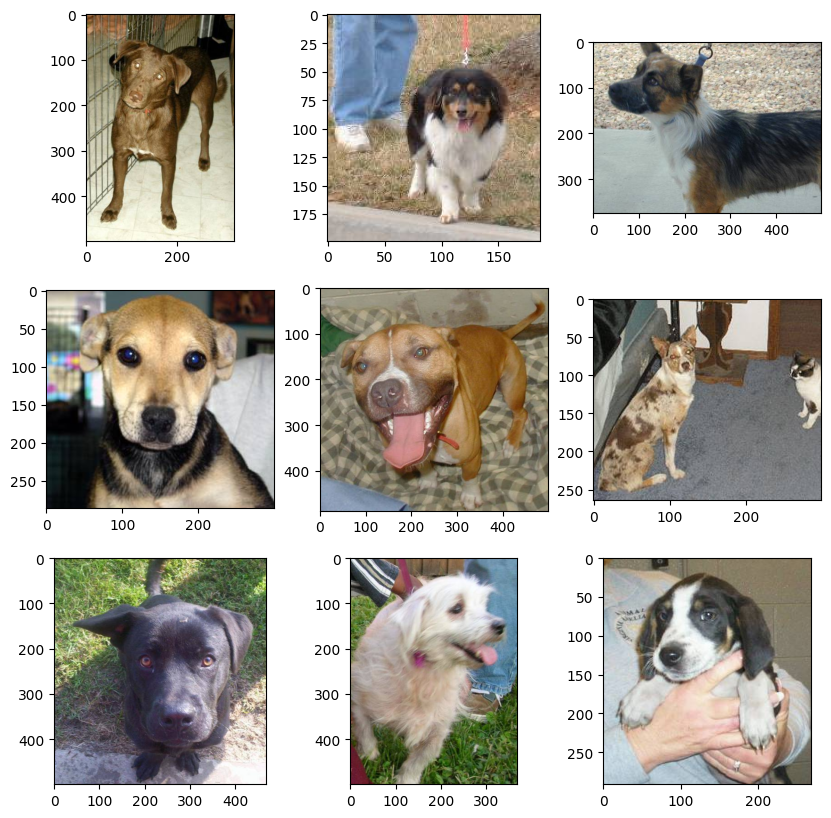

In [28]:
fotos_perros = '/content/data/processed/train/dog'
plt.figure(figsize=(10, 10))

plt.figure(figsize=(10, 10))
contador = 1
i = 1

while contador <= 9:
    filename = os.path.join(fotos_perros, f'dog.{i}.jpg')
    if os.path.exists(filename):
        plt.subplot(3, 3, contador)
        image = imread(filename)
        plt.imshow(image)
        contador += 1
    i += 1

plt.show()



<Figure size 1000x1000 with 0 Axes>

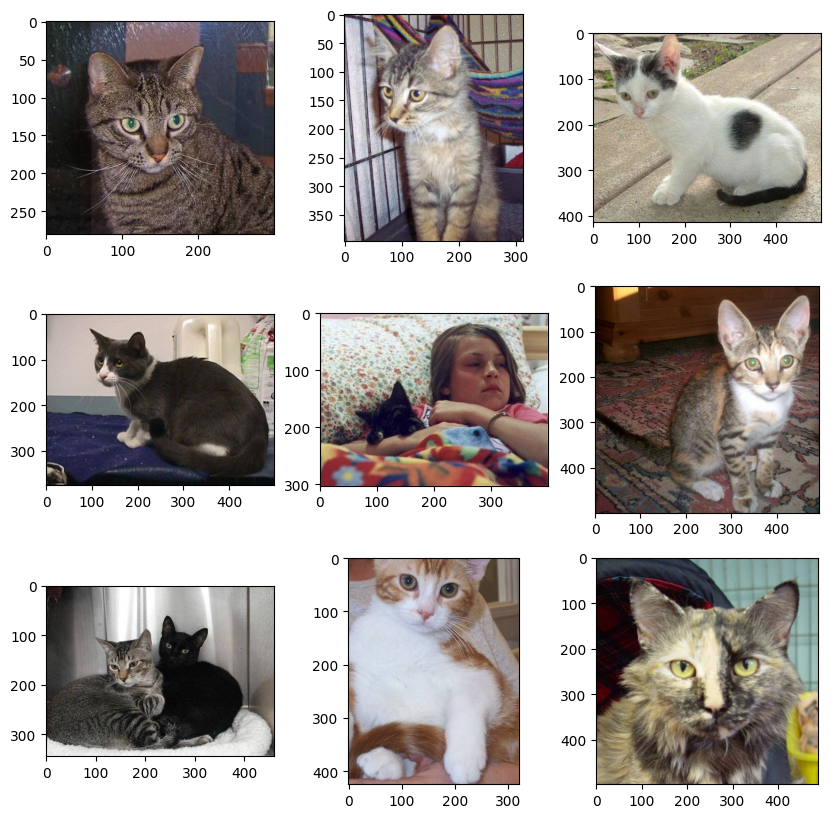

In [29]:
fotos_gatos = '/content/data/processed/train/cat'
plt.figure(figsize=(10, 10))

plt.figure(figsize=(10, 10))
contador = 1
i = 1

while contador <= 9:
    filename = os.path.join(fotos_gatos, f'cat.{i}.jpg')
    if os.path.exists(filename):
        plt.subplot(3, 3, contador)
        image = imread(filename)
        plt.imshow(image)
        contador += 1
    i += 1

plt.show()


In [30]:

trdata = ImageDataGenerator()
tsdata = ImageDataGenerator()


train_data = trdata.flow_from_directory(
    directory= "/content/data/processed/train",
    target_size= (200, 200),
    batch_size= 32,
    class_mode= 'categorical'
)

test_data = tsdata.flow_from_directory(
    directory= "/content/data/processed/test",
    target_size= (200, 200),
    batch_size= 32,
    class_mode= 'categorical'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


**Paso 3: Construye una RNA**

Cualquier clasificador que se ajuste a este problema tendrá que ser robusto porque algunas imágenes muestran al gato o al perro en una esquina o tal vez a 2 gatos o perros en la misma foto. Si has podido investigar algunas de las implementaciones de los ganadores de otras competiciones también relacionadas con imágenes, verás que VGG16 es una arquitectura de CNN utilizada para ganar la competencia de Kaggle ILSVR (Imagenet) en 2014. Se considera una de las arquitecturas de modelos de visión con mejores resultados hasta la fecha.

Utiliza la siguiente arquitectura de prueba:

In [31]:
model = Sequential()
model.add(Conv2D(input_shape = (200,200,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

model.compile(optimizer= Adam(learning_rate= 0.0001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

**Paso 4: Optimiza el modelo anterior**

Importa el método ModelCheckpoint y EarlyStopping de Keras. Crea un objeto de ambos y pásalo como funciones callback a fit_generator.

Carga el mejor modelo de los anteriores y utiliza el conjunto de test para hacer predicciones.

In [32]:
imagenes = 32
batchs = 32
pasos = imagenes // batchs
history1 = model.fit(
    train_data,steps_per_epoch= pasos,
    validation_data=test_data,
    epochs=2
)


Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 2685s 2685s/step - accuracy: 0.5938 - loss: 0.6818 - val_accuracy: 0.5000 - val_loss: 4.0866
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 2666s 2666s/step - accuracy: 0.5938 - loss: 3.3341 - val_accuracy: 0.5000 - val_loss: 2.5640


In [33]:
_, accuracy = model.evaluate(test_data)
print(f"Accuracy: {accuracy}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2585s 16s/step - accuracy: 0.5000 - loss: 2.5640
Accuracy: 0.5


In [34]:
early_stop = EarlyStopping(
    monitor= 'val_loss',
    patience= 5,          # Wait 5 epochs before giving up
    restore_best_weights= True
)

# 2. Create the ModelCheckpoint object
# This saves the 'Best' version of your manual bricks to your Drive
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/DOGS_CATS_PROJECT/gatos_perros_model.keras"
checkpoint = ModelCheckpoint(
    filepath= checkpoint_path,
    monitor= 'val_accuracy',
    save_best_only= True,
    verbose=1
)
history = model.fit(
    train_data,
    steps_per_epoch= pasos,
    validation_data= test_data,
    validation_steps= 31,
    epochs= 20,
    callbacks= [early_stop, checkpoint] )


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65s/step - accuracy: 0.4688 - loss: 2.7313
Epoch 1: val_accuracy improved from None to 0.47278, saving model to /content/drive/MyDrive/Colab Notebooks/DOGS_CATS_PROJECT/gatos_perros_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/DOGS_CATS_PROJECT/gatos_perros_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 616s 616s/step - accuracy: 0.4688 - loss: 2.7313 - val_accuracy: 0.4728 - val_loss: 0.7563
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85s/step - accuracy: 0.6250 - loss: 0.6614
Epoch 2: val_accuracy improved from 0.47278 to 0.50202, saving model to /content/drive/MyDrive/Colab Notebooks/DOGS_CATS_PROJECT/gatos_perros_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/DOGS_CATS_PROJECT/gatos_perros_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 690s 690s/step - accuracy: 0.6250 - loss: 0.6614 - val_accuracy: 0.5020 - val_loss: 0.6925
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85s/step - accuracy: 0.531

In [35]:
_, accuracy2 = model.evaluate(test_data)
print(f"Accuracy: {accuracy2}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2588s 16s/step - accuracy: 0.5000 - loss: 0.6943
Accuracy: 0.5


**Paso 5: Guarda el modelo**

In [39]:
model.save('/content/drive/MyDrive/Colab Notebooks/DOGS_CATS_PROJECT/gatos_perros_model.keras')


In [ ]:

#Imagen_test = '/content/data/processed/test/dog/dog.1.jpg'


#img = image.load_img(Imagen_test, target_size=(200, 200))
#img_array = image.img_to_array(img)
#img_array = np.expand_dims(img_array, axis=0)

#img_array = img_array / 255.0
#prediccion = loaded_model.predict(img_array)

#print(f"Predicción {Imagen_test}: {prediccion}")
